# Análisis ESG de empresas (Bloomberg BESG)Análisis descriptivo del archivo `07. T1_GC_datos.xlsx`.Contenido:1. Carga y estructura de los datos2. Calidad de los datos (valores faltantes)3. Estadísticas descriptivas básicas4. Distribución del puntaje ESG y sus tres pilares5. Agrupación por sector industrial6. Ranking de empresas por *BESG ESG Score*7. Relación entre ESG y variables financieras8. Exportación de resultados


## 1. Carga y estructura de los datos


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RUTA = "07. T1_GC_datos.xlsx"
HOJA = "datos"

df = pd.read_excel(RUTA, sheet_name=HOJA)
print(f"Filas: {df.shape[0]:,}   Columnas: {df.shape[1]}")
df.head()

Filas: 1,878   Columnas: 51


,Year,Ticker,Industry Sector,ROIC/WACC Ratio,Weighted Average Cost of Cap,Financial Leverage,Price to Book Ratio,Price Earnings Ratio (P/E),Revenue,EBITDA,Return on Common Equity,Return on Assets,Total Assets,Current Market Cap,Dividend 12 Month Yld - Gross,BESG ESG Score,BESG Environmental Pillar Score,BESG Social Pillar Score,BESG Governance Pillar Score,Environmental Disclosure Score,Social Disclosure Score,Governance Disclosure Score,Number of Independent Directors,Independent Directors Board Meeting Attendance %,Number of Women on Board,BESG BOD Diversity Issue Score,% Women on Board,Pct Women in Workforce,Independent Directors Board Meeting Attendance %.1,CEO Duality,Board Diversity Percentage,Board Average Age,Board Size,Gross Margin,Number of Employees,Short and Long Term Debt,Total Debt to EBITDA,Current Ratio,Total Debt to Total Equity,Total Debt to Total Assets,Operating Margin,Chg of Ctrl Benefits/Golden Parachute Agreements,Poison Pill Plan,Classified Board System,CEO Duality.1,Total Compensation Paid to Executives,Total Compensation Paid to CEO and Equivalent,Total Board of Director Compensation Paid,Number of CEO and Equivalent Changes During FY,Number of Board of Director Changes During FY,Number of Directors Included Compensation Paid
0,2023,AAPL US Equity,Technology,6.96,8.61,6.03,51.25,32.63,"391,035.00","136,661.00",136.52,27.57,"364,980.00","3,417,221,166,040.00",0.44,5.69,5.65,4.56,7.87,NaN,NaN,NaN,7.00,75.00,4.00,7.24,50.00,NaN,75.00,N,37.50,68.12,8.00,46.21,"164,000.00","119,059.00",0.70,0.87,209.06,32.62,31.51,N,N,N,N,"183,325,385.00","74,609,802.00","3,099,264.00",0.00,3.00,9.00
1,2023,MSFT US Equity,Technology,2.58,9.05,1.95,9.34,30.50,"245,122.00","135,275.00",34.29,18.47,"512,163.00","2,826,102,686,457.60",0.83,5.16,5.59,3.04,8.15,NaN,NaN,NaN,11.00,75.00,5.00,7.63,41.67,32.80,75.00,Y,25.00,59.83,12.00,69.76,"228,000.00","97,852.00",0.69,1.27,36.45,19.11,44.64,N,N,N,Y,"163,430,212.00","79,106,183.00","4,230,000.00",0.00,4.00,13.00
2,2023,NVDA US Equity,Technology,6.01,13.86,1.45,33.01,36.37,"130,497.00","83,673.00",119.18,82.20,"111,601.00","2,610,312,000,000.00",0.03,7.06,7.13,7.02,7.00,NaN,NaN,NaN,NaN,NaN,NaN,7.12,NaN,21.00,NaN,NaN,NaN,NaN,NaN,74.99,"36,000.00","10,270.00",0.12,4.44,12.95,9.20,62.42,NaN,N,NaN,NaN,"83,157,547.00","34,167,902.00","4,892,588.00",0.00,3.00,13.00
3,2023,AMZN US Equity,Communications,1.44,9.55,2.36,7.21,34.58,"637,959.00","133,349.00",24.29,10.28,"624,894.00","2,061,682,268,138.08",NaN,4.54,4.74,3.08,7.14,NaN,NaN,NaN,NaN,NaN,NaN,6.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.85,"1,556,000.00","147,838.00",1.11,1.06,51.70,23.66,10.75,NaN,N,NaN,NaN,"4,600,271.00","1,357,764.00","4,514,830.00",0.00,3.00,12.00
4,2023,GOOGL US Equity,Communications,3.74,8.84,1.40,6.23,20.93,"350,018.00","131,005.00",32.91,23.48,"450,256.00","2,033,453,680,000.00",0.48,4.15,4.68,2.61,6.70,NaN,NaN,NaN,NaN,NaN,NaN,3.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.20,"183,323.00","25,696.00",0.20,1.84,7.90,5.71,32.11,NaN,N,NaN,NaN,"147,396,768.00","8,802,824.00","3,627,134.00",0.00,1.00,10.00


In [2]:
# El archivo trae dos pares de columnas con nombre repetido; pandas les agrega el sufijo ".1".
# Verificamos si son redundantes antes de eliminarlas.
for base in ["Independent Directors Board Meeting Attendance %", "CEO Duality"]:
    a, b = df[base], df[f"{base}.1"]
    iguales = (
        a.astype("string").fillna("<NA>") == b.astype("string").fillna("<NA>")
    ).mean()
    print(f"{base!r}: coincidencia con su duplicado = {iguales:.1%}")

'Independent Directors Board Meeting Attendance %': coincidencia con su duplicado = 93.0%
'CEO Duality': coincidencia con su duplicado = 97.8%


In [3]:
# Nos quedamos con una sola copia de las columnas duplicadas
df = df.drop(columns=[c for c in df.columns if c.endswith(".1")])

# El ticker de Bloomberg viene como "AAPL US Equity"; extraemos el símbolo limpio
df["Simbolo"] = df["Ticker"].str.replace(r"\s+US Equity$", "", regex=True)

# Renombramos las columnas clave a nombres cortos para el análisis
COL_ESG = "BESG ESG Score"
COL_E = "BESG Environmental Pillar Score"
COL_S = "BESG Social Pillar Score"
COL_G = "BESG Governance Pillar Score"
PILARES = [COL_E, COL_S, COL_G]
SECTOR = "Industry Sector"

print("Años presentes:", sorted(df["Year"].unique()))
print("Tickers únicos:", df["Ticker"].nunique(), "| Filas:", len(df))
print("Sectores:", df[SECTOR].nunique())

Años presentes: [np.int64(2023)]
Tickers únicos: 1878 | Filas: 1878
Sectores: 10


El panel es un **corte transversal**: un único año fiscal (2023) y un ticker por fila, sin repeticiones.Por lo tanto no hay dimensión temporal y todo el análisis es de sección cruzada.


In [4]:
df.dtypes.to_frame("tipo")

,tipo
Year,int64
Ticker,str
Industry Sector,str
ROIC/WACC Ratio,float64
Weighted Average Cost of Cap,float64
Financial Leverage,float64
Price to Book Ratio,float64
Price Earnings Ratio (P/E),float64
Revenue,float64
EBITDA,float64


## 2. Calidad de los datos: valores faltantes


In [5]:
faltantes = (
    df.isna()
    .sum()
    .to_frame("n_faltantes")
    .assign(pct_faltantes=lambda d: 100 * d["n_faltantes"] / len(df))
    .sort_values("n_faltantes", ascending=False)
)
faltantes[faltantes["n_faltantes"] > 0]

,n_faltantes,pct_faltantes
Governance Disclosure Score,1720,91.59
Social Disclosure Score,1720,91.59
Environmental Disclosure Score,1720,91.59
Board Diversity Percentage,1639,87.27
Independent Directors Board Meeting Attendance %,1488,79.23
Classified Board System,1450,77.21
Board Average Age,1446,77.00
Chg of Ctrl Benefits/Golden Parachute Agreements,1446,77.00
% Women on Board,1441,76.73
Board Size,1440,76.68


In [6]:
cobertura = pd.DataFrame(
    {
        "con_dato": [df[c].notna().sum() for c in [COL_ESG] + PILARES],
        "sin_dato": [df[c].isna().sum() for c in [COL_ESG] + PILARES],
    },
    index=["ESG total", "Ambiental (E)", "Social (S)", "Gobernanza (G)"],
)
cobertura["pct_cobertura"] = 100 * cobertura["con_dato"] / len(df)
print(cobertura)

# Universo de trabajo para rankings: empresas con puntaje ESG informado
esg = df[df[COL_ESG].notna()].copy()
print(
    f"\nEmpresas con ESG Score informado: {len(esg):,} de {len(df):,} "
    f"({100 * len(esg) / len(df):.1f}%)"
)

                con_dato  sin_dato  pct_cobertura
ESG total           1433       445          76.30
Ambiental (E)       1433       445          76.30
Social (S)          1433       445          76.30
Gobernanza (G)      1433       445          76.30

Empresas con ESG Score informado: 1,433 de 1,878 (76.3%)


**Nota metodológica:** las empresas sin puntaje ESG se excluyen de los rankings, no se imputan.Imputar un puntaje ESG con la media introduciría un sesgo directo sobre la variable que se quiere ordenar.


## 3. Estadísticas descriptivas básicas


### 3.1 Puntajes ESG y de divulgación (_disclosure_)


In [7]:
COLS_ESG_TODAS = [
    COL_ESG,
    COL_E,
    COL_S,
    COL_G,
    "Environmental Disclosure Score",
    "Social Disclosure Score",
    "Governance Disclosure Score",
    "BESG BOD Diversity Issue Score",
]


def describir(frame, columnas):
    """Tabla de estadísticas descriptivas con asimetría y curtosis."""
    d = frame[columnas].describe().T
    d = d.rename(
        columns={
            "count": "n",
            "mean": "media",
            "std": "desv_est",
            "min": "min",
            "25%": "p25",
            "50%": "mediana",
            "75%": "p75",
            "max": "max",
        }
    )
    d["rango"] = d["max"] - d["min"]
    d["cv"] = d["desv_est"] / d["media"]
    d["asimetria"] = frame[columnas].skew()
    d["curtosis"] = frame[columnas].kurtosis()
    return d


describir(df, COLS_ESG_TODAS)

,n,media,desv_est,min,p25,mediana,p75,max,rango,cv,asimetria,curtosis
BESG ESG Score,"1,433.00",3.97,1.52,0.78,2.68,3.96,5.12,8.47,7.69,0.38,0.13,-0.87
BESG Environmental Pillar Score,"1,433.00",2.88,2.34,0.00,0.50,2.87,4.71,9.43,9.43,0.81,0.32,-0.94
BESG Social Pillar Score,"1,433.00",3.29,2.12,0.00,1.63,2.74,4.55,10.00,10.00,0.64,0.81,-0.01
BESG Governance Pillar Score,"1,433.00",6.92,1.16,2.02,6.36,7.14,7.74,9.10,7.08,0.17,-1.31,2.37
Environmental Disclosure Score,158.00,20.80,18.23,0.00,0.66,18.18,33.52,69.07,69.07,0.88,0.50,-0.65
Social Disclosure Score,158.00,24.01,11.06,5.74,14.42,22.19,31.09,61.19,55.44,0.46,0.67,-0.15
Governance Disclosure Score,158.00,76.52,15.71,6.26,62.04,83.59,87.48,100.00,93.74,0.21,-1.16,1.40
BESG BOD Diversity Issue Score,"1,433.00",5.82,1.63,0.48,4.75,5.72,6.95,9.82,9.34,0.28,0.03,-0.16


### 3.2 Variables financieras


In [8]:
COLS_FIN = [
    "Revenue",
    "EBITDA",
    "Total Assets",
    "Current Market Cap",
    "Return on Common Equity",
    "Return on Assets",
    "ROIC/WACC Ratio",
    "Weighted Average Cost of Cap",
    "Gross Margin",
    "Operating Margin",
    "Price to Book Ratio",
    "Price Earnings Ratio (P/E)",
    "Financial Leverage",
    "Total Debt to Total Equity",
    "Total Debt to Total Assets",
    "Total Debt to EBITDA",
    "Current Ratio",
    "Dividend 12 Month Yld - Gross",
    "Number of Employees",
]
describir(df, COLS_FIN)

,n,media,desv_est,min,p25,mediana,p75,max,rango,cv,asimetria,curtosis
Revenue,"1,491.00","17,447.65","58,957.00",0.00,"1,589.56","4,321.86","12,071.10","1,158,819.00","1,158,819.00",3.38,10.81,159.67
EBITDA,"1,360.00","3,424.88","12,212.83","-17,747.74",316.00,866.80,"2,277.37","168,606.00","186,353.74",3.57,8.57,85.47
Total Assets,"1,492.00","48,884.81","233,025.66",12.88,"3,405.83","9,120.45","26,926.47","4,349,731.00","4,349,718.12",4.77,13.03,197.57
Current Market Cap,"1,878.00","33,740,362,991.39","154,086,494,137.31","2,377,098,144.53","4,287,250,732.42","8,143,018,292.68","19,725,979,003.91","3,417,221,166,040.00","3,414,844,067,895.47",4.57,14.77,259.29
Return on Common Equity,"1,385.00",14.79,46.88,-628.33,5.53,12.46,22.50,704.02,"1,332.35",3.17,0.95,76.36
Return on Assets,"1,471.00",3.87,13.34,-150.03,1.19,4.34,8.88,82.20,232.23,3.45,-3.00,24.09
ROIC/WACC Ratio,"1,492.00",0.71,5.65,-187.13,0.33,0.91,1.56,65.22,252.36,7.91,-23.94,833.52
Weighted Average Cost of Cap,"1,492.00",8.49,2.42,-7.34,7.06,8.05,9.42,45.29,52.64,0.28,3.19,39.82
Gross Margin,"1,128.00",45.25,24.46,-114.27,27.32,42.25,63.49,99.84,214.11,0.54,-0.27,1.78
Operating Margin,"1,475.00",-321.12,"11,458.93","-438,789.71",5.66,14.22,24.11,"3,399.19","442,188.89",-35.68,-38.08,"1,457.36"


### 3.3 Variables de gobierno corporativo


In [9]:
COLS_GOB = [
    "Board Size",
    "Board Average Age",
    "Number of Independent Directors",
    "Independent Directors Board Meeting Attendance %",
    "Number of Women on Board",
    "% Women on Board",
    "Pct Women in Workforce",
    "Board Diversity Percentage",
    "Total Compensation Paid to Executives",
    "Total Compensation Paid to CEO and Equivalent",
    "Total Board of Director Compensation Paid",
    "Number of CEO and Equivalent Changes During FY",
    "Number of Board of Director Changes During FY",
]
describir(df, COLS_GOB)

,n,media,desv_est,min,p25,mediana,p75,max,rango,cv,asimetria,curtosis
Board Size,438.00,9.66,2.16,3.00,8.00,10.00,11.00,17.00,14.00,0.22,0.17,0.76
Board Average Age,432.00,61.00,5.32,42.25,58.53,61.77,64.38,80.40,38.15,0.09,-0.62,1.13
Number of Independent Directors,470.00,7.98,2.58,2.00,6.00,8.00,10.00,15.00,13.00,0.32,-0.16,-0.21
Independent Directors Board Meeting Attendance %,390.00,79.83,9.02,73.33,75.00,75.00,75.00,100.00,26.67,0.11,1.49,0.46
Number of Women on Board,480.00,3.01,1.36,0.00,2.00,3.00,4.00,7.00,7.00,0.45,0.09,0.02
% Women on Board,437.00,28.91,11.29,0.00,22.22,30.00,36.36,66.67,66.67,0.39,-0.26,0.40
Pct Women in Workforce,471.00,41.72,17.07,5.00,28.00,41.00,53.00,94.00,89.00,0.41,0.30,-0.48
Board Diversity Percentage,239.00,23.07,13.06,0.00,12.50,22.22,30.00,80.00,80.00,0.57,0.95,2.48
Total Compensation Paid to Executives,"1,396.00","33,633,910.12","51,940,628.08",0.00,"15,807,327.25","25,427,460.50","39,253,362.50","1,607,000,000.00","1,607,000,000.00",1.54,20.91,608.27
Total Compensation Paid to CEO and Equivalent,"1,363.00","14,177,904.62","15,864,492.51",0.00,"6,752,847.00","10,825,450.00","16,999,317.00","246,230,000.00","246,230,000.00",1.12,6.52,67.26


In [10]:
# Variables categóricas de gobierno corporativo (S / N)
COLS_SN = [
    "CEO Duality",
    "Chg of Ctrl Benefits/Golden Parachute Agreements",
    "Poison Pill Plan",
    "Classified Board System",
]
resumen_sn = pd.concat(
    {
        c: df[c].value_counts(dropna=False, normalize=True).mul(100).round(1)
        for c in COLS_SN
    },
    axis=1,
)
resumen_sn.rename_axis("respuesta")

,CEO Duality,Chg of Ctrl Benefits/Golden Parachute Agreements,Poison Pill Plan,Classified Board System
respuesta,,,,
NaN,76.50,77.00,40.50,77.20
N,15.30,4.70,58.90,15.20
Y,8.20,18.30,0.60,7.60


## 4. Distribución del puntaje ESG y sus pilares


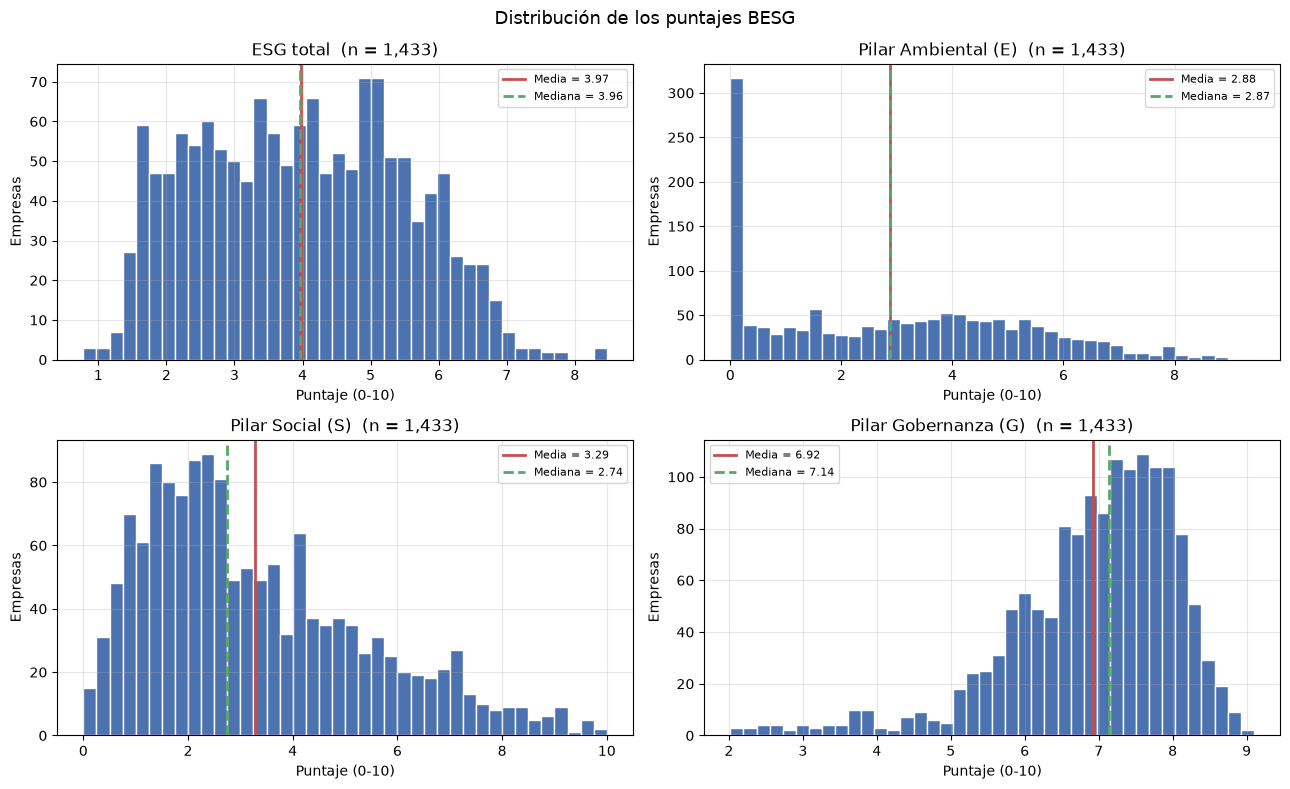

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
titulos = {
    COL_ESG: "ESG total",
    COL_E: "Pilar Ambiental (E)",
    COL_S: "Pilar Social (S)",
    COL_G: "Pilar Gobernanza (G)",
}
for ax, (col, titulo) in zip(axes.ravel(), titulos.items()):
    serie = df[col].dropna()
    ax.hist(serie, bins=40, color="#4C72B0", edgecolor="white")
    ax.axvline(serie.mean(), color="#C44E52", lw=2, label=f"Media = {serie.mean():.2f}")
    ax.axvline(
        serie.median(),
        color="#55A868",
        lw=2,
        ls="--",
        label=f"Mediana = {serie.median():.2f}",
    )
    ax.set_title(f"{titulo}  (n = {serie.count():,})")
    ax.set_xlabel("Puntaje (0-10)")
    ax.set_ylabel("Empresas")
    ax.legend(fontsize=8)

fig.suptitle("Distribución de los puntajes BESG", fontsize=13)
fig.tight_layout()
plt.show()

Matriz de correlación (Pearson) entre ESG total y pilares:
                                 BESG ESG Score  BESG Environmental Pillar Score  BESG Social Pillar Score  BESG Governance Pillar Score
BESG ESG Score                             1.00                             0.79                      0.82                          0.43
BESG Environmental Pillar Score            0.79                             1.00                      0.42                          0.21
BESG Social Pillar Score                   0.82                             0.42                      1.00                          0.24
BESG Governance Pillar Score               0.43                             0.21                      0.24                          1.00


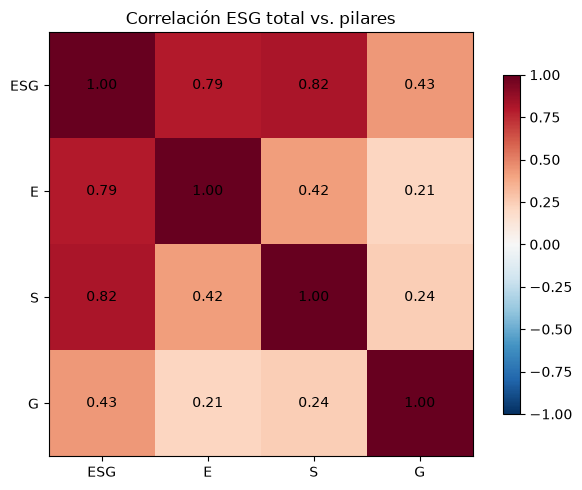

In [12]:
# Correlación entre el puntaje total y cada pilar
corr_pilares = df[[COL_ESG] + PILARES].corr()
print("Matriz de correlación (Pearson) entre ESG total y pilares:")
print(corr_pilares.round(3))

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corr_pilares, cmap="RdBu_r", vmin=-1, vmax=1)
etiquetas = ["ESG", "E", "S", "G"]
ax.set_xticks(range(4), etiquetas)
ax.set_yticks(range(4), etiquetas)
for i in range(4):
    for j in range(4):
        ax.text(
            j,
            i,
            f"{corr_pilares.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=10,
        )
ax.set_title("Correlación ESG total vs. pilares")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

## 5. Agrupación por sector industrial


### 5.1 Composición de la muestra por sector


In [13]:
composicion = (
    df.groupby(SECTOR)
    .agg(
        empresas=("Ticker", "count"),
        con_esg=(COL_ESG, "count"),
        market_cap_total=("Current Market Cap", "sum"),
        ingresos_totales=("Revenue", "sum"),
        empleados_totales=("Number of Employees", "sum"),
    )
    .assign(
        pct_muestra=lambda d: 100 * d["empresas"] / d["empresas"].sum(),
        pct_cobertura_esg=lambda d: 100 * d["con_esg"] / d["empresas"],
    )
    .sort_values("empresas", ascending=False)
)
composicion

,empresas,con_esg,market_cap_total,ingresos_totales,empleados_totales,pct_muestra,pct_cobertura_esg
Industry Sector,,,,,,,
Funds,383,0,"3,636,172,101,562.50",0.00,0.00,20.39,0.00
Financial,312,306,"9,628,442,140,613.35","3,991,431.80","4,161,900.00",16.61,98.08
"Consumer, Non-cyclical",295,286,"9,739,027,753,755.93","5,221,163.20","7,542,560.00",15.71,96.95
Industrial,215,208,"4,649,159,441,405.57","2,196,059.55","5,634,647.00",11.45,96.74
"Consumer, Cyclical",200,189,"5,636,179,747,734.45","4,351,603.29","10,762,117.00",10.65,94.50
Technology,193,177,"15,635,696,302,920.60","2,130,917.08","4,878,452.00",10.28,91.71
Communications,99,94,"9,805,269,862,195.67","5,352,714.92","4,542,944.00",5.27,94.95
Energy,76,70,"2,247,104,466,438.85","1,725,111.50","626,166.00",4.05,92.11
Utilities,57,55,"1,335,108,871,075.09","505,990.55","383,391.00",3.04,96.49


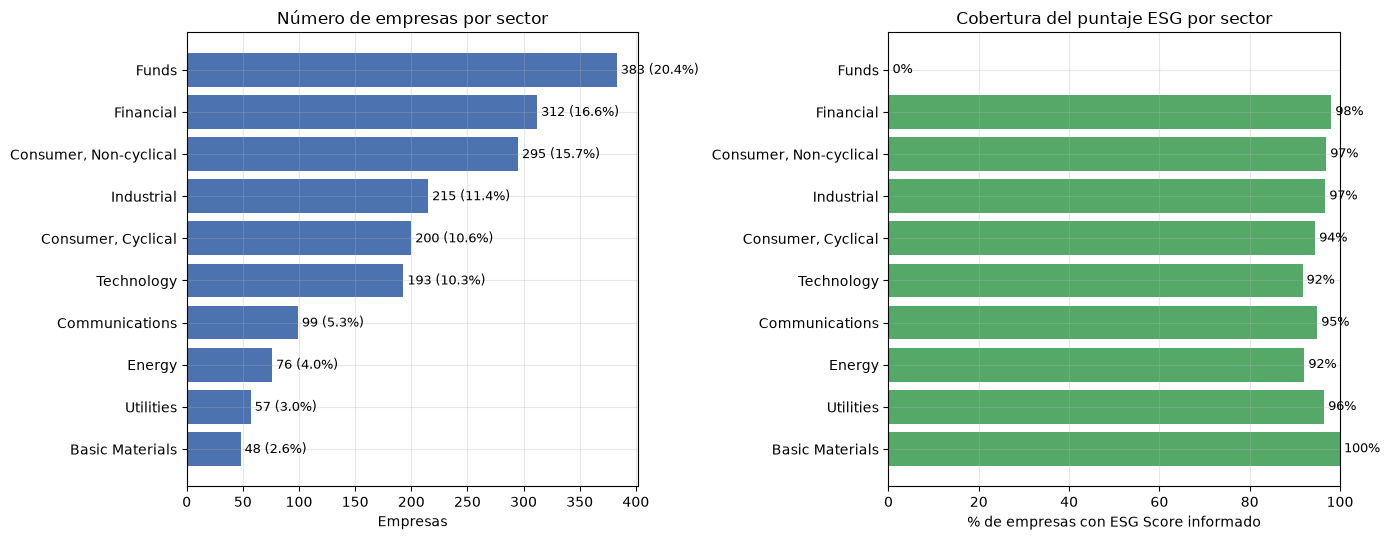

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

comp = composicion.sort_values("empresas")
axes[0].barh(comp.index, comp["empresas"], color="#4C72B0")
axes[0].set_title("Número de empresas por sector")
axes[0].set_xlabel("Empresas")
for y, (n, pct) in enumerate(zip(comp["empresas"], comp["pct_muestra"])):
    axes[0].text(n, y, f" {n} ({pct:.1f}%)", va="center", fontsize=9)

axes[1].barh(comp.index, comp["pct_cobertura_esg"], color="#55A868")
axes[1].set_title("Cobertura del puntaje ESG por sector")
axes[1].set_xlabel("% de empresas con ESG Score informado")
axes[1].set_xlim(0, 100)
for y, pct in enumerate(comp["pct_cobertura_esg"]):
    axes[1].text(pct, y, f" {pct:.0f}%", va="center", fontsize=9)

fig.tight_layout()
plt.show()

### 5.2 Estadísticas del puntaje ESG por sector


In [15]:
stats_sector = (
    esg.groupby(SECTOR)[COL_ESG]
    .agg(
        n="count",
        media="mean",
        mediana="median",
        desv_est="std",
        min="min",
        max="max",
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
    )
    .assign(
        rango_iq=lambda d: d["p75"] - d["p25"],
        cv=lambda d: d["desv_est"] / d["media"],
    )
    .sort_values("media", ascending=False)
)
stats_sector

,n,media,mediana,desv_est,min,max,p25,p75,rango_iq,cv
Industry Sector,,,,,,,,,,
Basic Materials,48,5.04,5.12,1.33,2.27,7.44,4.07,6.14,2.07,0.26
Utilities,55,4.98,5.18,1.15,2.03,6.81,4.68,5.73,1.05,0.23
Energy,70,4.58,4.95,1.25,1.59,7.09,3.72,5.44,1.72,0.27
Industrial,208,4.34,4.34,1.50,1.55,8.41,3.12,5.35,2.23,0.35
"Consumer, Cyclical",189,4.09,4.08,1.51,0.78,7.81,3.00,5.09,2.09,0.37
"Consumer, Non-cyclical",286,3.88,3.96,1.52,0.92,7.01,2.63,5.09,2.46,0.39
Technology,177,3.79,3.81,1.50,1.32,7.54,2.46,4.92,2.46,0.40
Communications,94,3.59,3.48,1.38,1.02,6.82,2.67,4.68,2.01,0.38
Financial,306,3.46,3.07,1.44,1.05,8.47,2.27,4.54,2.27,0.42


**Advertencia sobre la clasificación sectorial:** el sector `Funds` agrupa fondos y vehículos
de inversión, no empresas operativas. Su puntaje ESG no es comparable con el de una industrial o
una minera, porque no tienen operaciones propias que generar emisiones ni plantilla que gestionar.
Lo mismo aplica en menor grado a `Financial`. La siguiente celda repite las estadísticas
excluyendo `Funds` para ver cuánto cambia la lectura.


In [16]:
NO_OPERATIVOS = ["Funds"]
esg_op = esg[~esg[SECTOR].isin(NO_OPERATIVOS)]

comparativo = pd.DataFrame(
    {
        "universo_completo": esg[COL_ESG].describe(),
        "sin_Funds": esg_op[COL_ESG].describe(),
    }
)
print(comparativo.round(3))
print(f"\nFilas excluidas: {len(esg) - len(esg_op):,}")

stats_sector_op = (
    esg_op.groupby(SECTOR)[COL_ESG]
    .agg(
        n="count", media="mean", mediana="median", desv_est="std", min="min", max="max"
    )
    .sort_values("media", ascending=False)
)
stats_sector_op

       universo_completo  sin_Funds
count           1,433.00   1,433.00
mean                3.97       3.97
std                 1.52       1.52
min                 0.78       0.78
25%                 2.68       2.68
50%                 3.96       3.96
75%                 5.12       5.12
max                 8.47       8.47

Filas excluidas: 0


,n,media,mediana,desv_est,min,max
Industry Sector,,,,,,
Basic Materials,48,5.04,5.12,1.33,2.27,7.44
Utilities,55,4.98,5.18,1.15,2.03,6.81
Energy,70,4.58,4.95,1.25,1.59,7.09
Industrial,208,4.34,4.34,1.50,1.55,8.41
"Consumer, Cyclical",189,4.09,4.08,1.51,0.78,7.81
"Consumer, Non-cyclical",286,3.88,3.96,1.52,0.92,7.01
Technology,177,3.79,3.81,1.50,1.32,7.54
Communications,94,3.59,3.48,1.38,1.02,6.82
Financial,306,3.46,3.07,1.44,1.05,8.47


In [17]:
# Media de cada pilar por sector
pilares_sector = (
    df.groupby(SECTOR)[[COL_ESG] + PILARES]
    .mean()
    .rename(
        columns={
            COL_ESG: "ESG",
            COL_E: "Ambiental",
            COL_S: "Social",
            COL_G: "Gobernanza",
        }
    )
    .sort_values("ESG", ascending=False)
)
pilares_sector

,ESG,Ambiental,Social,Gobernanza
Industry Sector,,,,
Basic Materials,5.04,4.43,4.26,7.21
Utilities,4.98,3.72,4.74,7.74
Energy,4.58,3.94,3.56,6.98
Industrial,4.34,3.27,3.71,7.13
"Consumer, Cyclical",4.09,3.02,3.50,6.94
"Consumer, Non-cyclical",3.88,2.85,2.76,6.87
Technology,3.79,3.23,2.59,6.75
Communications,3.59,3.14,2.92,5.85
Financial,3.46,1.66,3.40,7.03


### 5.3 Ranking de sectores por puntaje ESG promedio


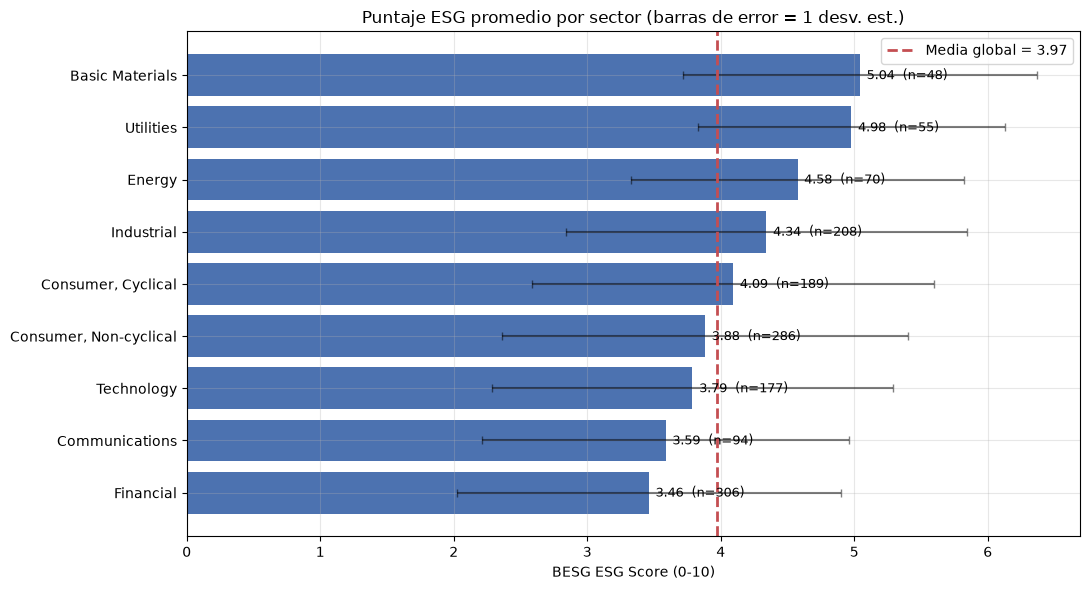

In [18]:
orden = stats_sector.sort_values("media")
fig, ax = plt.subplots(figsize=(11, 6))
barras = ax.barh(
    orden.index,
    orden["media"],
    color="#4C72B0",
    xerr=orden["desv_est"],
    capsize=3,
    error_kw={"alpha": 0.5},
)
media_global = esg[COL_ESG].mean()
ax.axvline(
    media_global,
    color="#C44E52",
    ls="--",
    lw=2,
    label=f"Media global = {media_global:.2f}",
)
for y, (m, n) in enumerate(zip(orden["media"], orden["n"])):
    ax.text(m + 0.05, y, f"{m:.2f}  (n={n})", va="center", fontsize=9)
ax.set_title("Puntaje ESG promedio por sector (barras de error = 1 desv. est.)")
ax.set_xlabel("BESG ESG Score (0-10)")
ax.legend()
fig.tight_layout()
plt.show()

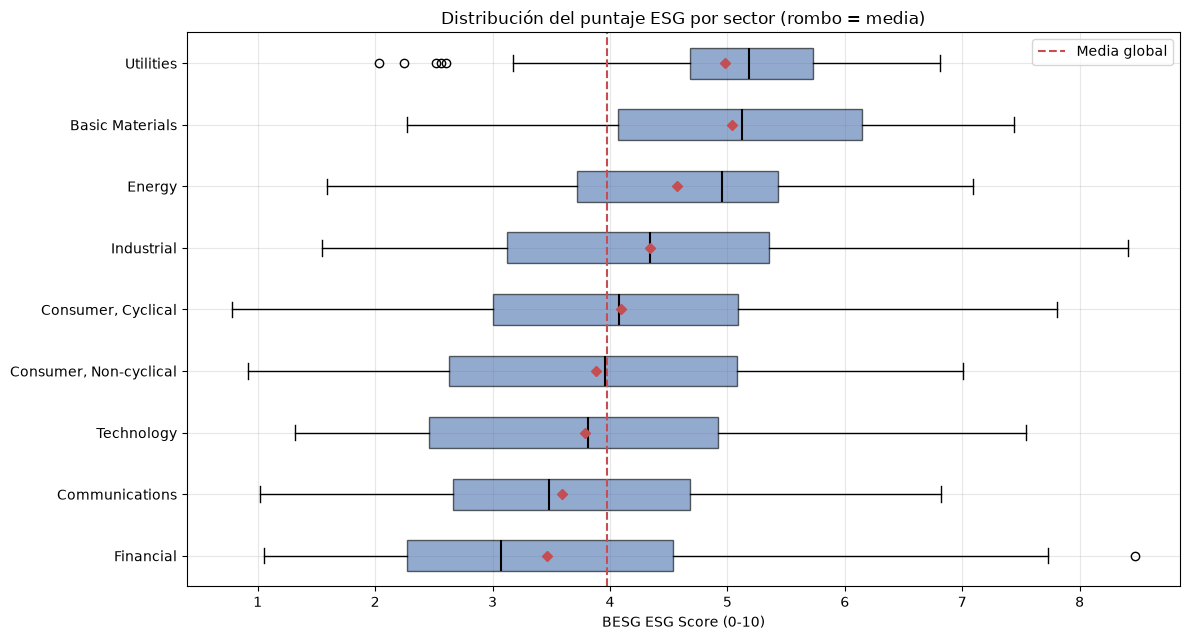

In [19]:
# Distribución completa por sector: el boxplot muestra dispersión, no solo el promedio
orden_mediana = esg.groupby(SECTOR)[COL_ESG].median().sort_values().index.tolist()
datos_box = [esg.loc[esg[SECTOR] == s, COL_ESG].values for s in orden_mediana]

fig, ax = plt.subplots(figsize=(12, 6.5))
bp = ax.boxplot(
    datos_box,
    orientation="horizontal",
    tick_labels=orden_mediana,
    patch_artist=True,
    medianprops={"color": "black", "lw": 1.5},
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "#C44E52",
        "markeredgecolor": "#C44E52",
        "markersize": 5,
    },
)
for caja in bp["boxes"]:
    caja.set(facecolor="#4C72B0", alpha=0.6)
ax.axvline(media_global, color="#C44E52", ls="--", lw=1.5, label="Media global")
ax.set_title("Distribución del puntaje ESG por sector (rombo = media)")
ax.set_xlabel("BESG ESG Score (0-10)")
ax.legend()
fig.tight_layout()
plt.show()

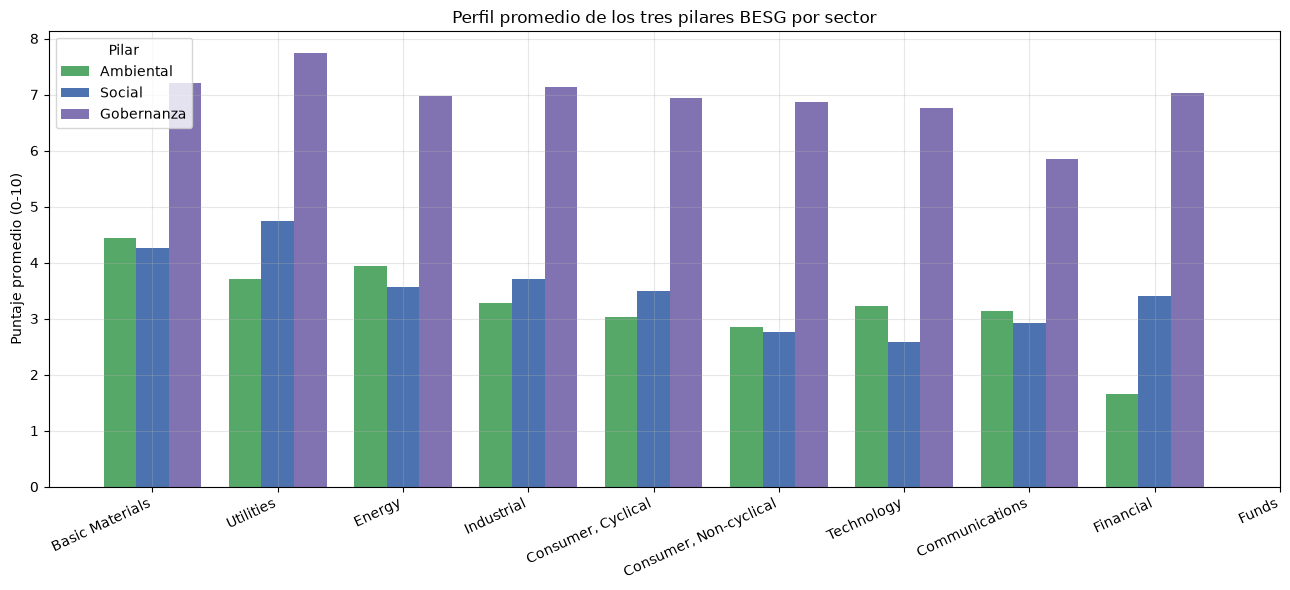

In [20]:
# Perfil de pilares por sector: barras agrupadas
perfil = pilares_sector[["Ambiental", "Social", "Gobernanza"]]
x = np.arange(len(perfil))
ancho = 0.26
colores = ["#55A868", "#4C72B0", "#8172B2"]

fig, ax = plt.subplots(figsize=(13, 6))
for i, (col, color) in enumerate(zip(perfil.columns, colores)):
    ax.bar(x + (i - 1) * ancho, perfil[col], ancho, label=col, color=color)
ax.set_xticks(x, perfil.index, rotation=25, ha="right")
ax.set_ylabel("Puntaje promedio (0-10)")
ax.set_title("Perfil promedio de los tres pilares BESG por sector")
ax.legend(title="Pilar")
fig.tight_layout()
plt.show()

### 5.4 ¿Las diferencias entre sectores son estadísticamente significativas?Se aplica un ANOVA de una vía y la prueba no paramétrica de Kruskal-Wallis, que no exige normalidad.


In [21]:
from scipy import stats

grupos = [g[COL_ESG].values for _, g in esg.groupby(SECTOR)]

f_stat, p_anova = stats.f_oneway(*grupos)
h_stat, p_kw = stats.kruskal(*grupos)

print(f"ANOVA de una vía:      F = {f_stat:.3f}   p-valor = {p_anova:.3e}")
print(f"Kruskal-Wallis:        H = {h_stat:.3f}   p-valor = {p_kw:.3e}")

# Eta cuadrado: proporción de la varianza del ESG explicada por el sector
media_gral = esg[COL_ESG].mean()
ss_entre = sum(len(g) * (g.mean() - media_gral) ** 2 for g in grupos)
ss_total = ((esg[COL_ESG] - media_gral) ** 2).sum()
print(f"\nEta cuadrado (varianza explicada por el sector) = {ss_entre / ss_total:.1%}")

ANOVA de una vía:      F = 15.869   p-valor = 1.368e-22
Kruskal-Wallis:        H = 119.162   p-valor = 4.938e-22

Eta cuadrado (varianza explicada por el sector) = 8.2%


## 6. Ranking de empresas por _BESG ESG Score_


In [22]:
COLS_RANKING = [
    "Simbolo",
    "Ticker",
    SECTOR,
    COL_ESG,
    COL_E,
    COL_S,
    COL_G,
    "Current Market Cap",
    "Revenue",
    "Return on Common Equity",
]

ranking = esg.sort_values(COL_ESG, ascending=False)[COLS_RANKING].reset_index(drop=True)
ranking.insert(0, "Puesto", np.arange(1, len(ranking) + 1))

# Percentil y ranking dentro del propio sector
ranking["Percentil"] = ranking[COL_ESG].rank(pct=True).mul(100).round(1)
ranking["Puesto_sector"] = (
    ranking.groupby(SECTOR)[COL_ESG].rank(ascending=False, method="min").astype(int)
)
ranking["N_sector"] = ranking.groupby(SECTOR)[COL_ESG].transform("size")

print(f"Empresas rankeadas: {len(ranking):,}")
ranking.head(25)

Empresas rankeadas: 1,433


,Puesto,Simbolo,Ticker,Industry Sector,BESG ESG Score,BESG Environmental Pillar Score,BESG Social Pillar Score,BESG Governance Pillar Score,Current Market Cap,Revenue,Return on Common Equity,Percentil,Puesto_sector,N_sector
0,1,CBOE,CBOE US Equity,Financial,8.47,7.79,8.98,8.25,"22,931,765,238.90","2,072.40",18.46,100.00,1,306
1,2,ETN,ETN US Equity,Industrial,8.41,7.89,9.59,7.97,"108,823,120,000.00","24,878.00",20.22,99.90,1,208
2,3,LII,LII US Equity,Industrial,8.28,8.48,9.17,7.17,"21,512,176,447.68","5,341.30",142.12,99.90,2,208
3,4,LVS,LVS US Equity,"Consumer, Cyclical",7.81,8.57,9.00,5.14,"32,460,477,983.14","11,298.00",41.30,99.80,1,189
4,5,CME,CME US Equity,Financial,7.73,7.58,9.24,5.98,"94,514,515,791.36","6,130.10",13.08,99.70,2,306
5,6,GD,GD US Equity,Industrial,7.70,5.69,9.05,7.40,"73,519,195,192.30","47,716.00",17.44,99.70,3,208
6,7,QCOM,QCOM US Equity,Technology,7.54,7.06,8.03,7.69,"171,407,880,000.00","38,962.00",42.27,99.60,1,177
7,8,FMC,FMC US Equity,Basic Materials,7.44,7.17,8.54,6.84,"5,193,505,367.82","4,246.10",7.64,99.50,1,48
8,9,EMR,EMR US Equity,Industrial,7.37,8.90,6.58,6.72,"63,060,937,000.00","17,492.00",11.71,99.40,4,208
9,10,FCX,FCX US Equity,Basic Materials,7.32,6.40,7.75,8.38,"49,579,018,707.00","25,455.00",10.99,99.40,2,48


### 6.1 Las 25 empresas con menor puntaje ESG


In [23]:
ranking.tail(25).sort_values("Puesto")

,Puesto,Simbolo,Ticker,Industry Sector,BESG ESG Score,BESG Environmental Pillar Score,BESG Social Pillar Score,BESG Governance Pillar Score,Current Market Cap,Revenue,Return on Common Equity,Percentil,Puesto_sector,N_sector
1408,1409,RITM,RITM US Equity,Financial,1.45,0.00,0.92,4.88,"5,998,004,156.16","5,047.39",13.59,1.70,299,306
1409,1410,BRK/A,BRK/A US Equity,Financial,1.45,0.00,1.00,5.07,"1,072,025,688,162.90","424,232.00",14.70,1.70,299,306
1410,1411,FUTU,FUTU US Equity,Financial,1.44,0.00,1.35,2.94,"14,945,840,702.66","10,008.42",17.13,1.60,301,306
1411,1412,FG,FG US Equity,Financial,1.40,0.00,0.44,5.89,"4,964,456,251.48","5,744.00",17.64,1.50,302,306
1412,1413,IONQ,IONQ US Equity,Technology,1.39,0.00,0.27,6.05,"4,071,326,610.33",43.07,-76.34,1.40,174,177
1413,1414,TGTX,TGTX US Equity,"Consumer, Non-cyclical",1.39,0.00,0.39,4.48,"6,161,878,657.25",329.00,12.21,1.40,283,286
1414,1415,INTA,INTA US Equity,Technology,1.38,0.00,0.43,5.47,"4,542,350,426.40",430.52,-5.29,1.30,175,177
1415,1416,SATS,SATS US Equity,Communications,1.38,0.00,0.49,5.70,"7,212,629,099.68","15,825.52",-0.60,1.30,89,94
1416,1417,AI,AI US Equity,Technology,1.37,0.00,0.43,5.43,"2,782,203,613.12",310.58,-32.07,1.20,176,177
1417,1418,PAY,PAY US Equity,"Consumer, Non-cyclical",1.36,0.00,0.39,5.50,"3,075,956,655.68",871.75,5.40,1.00,284,286


### 6.2 Top 25 global: visualización


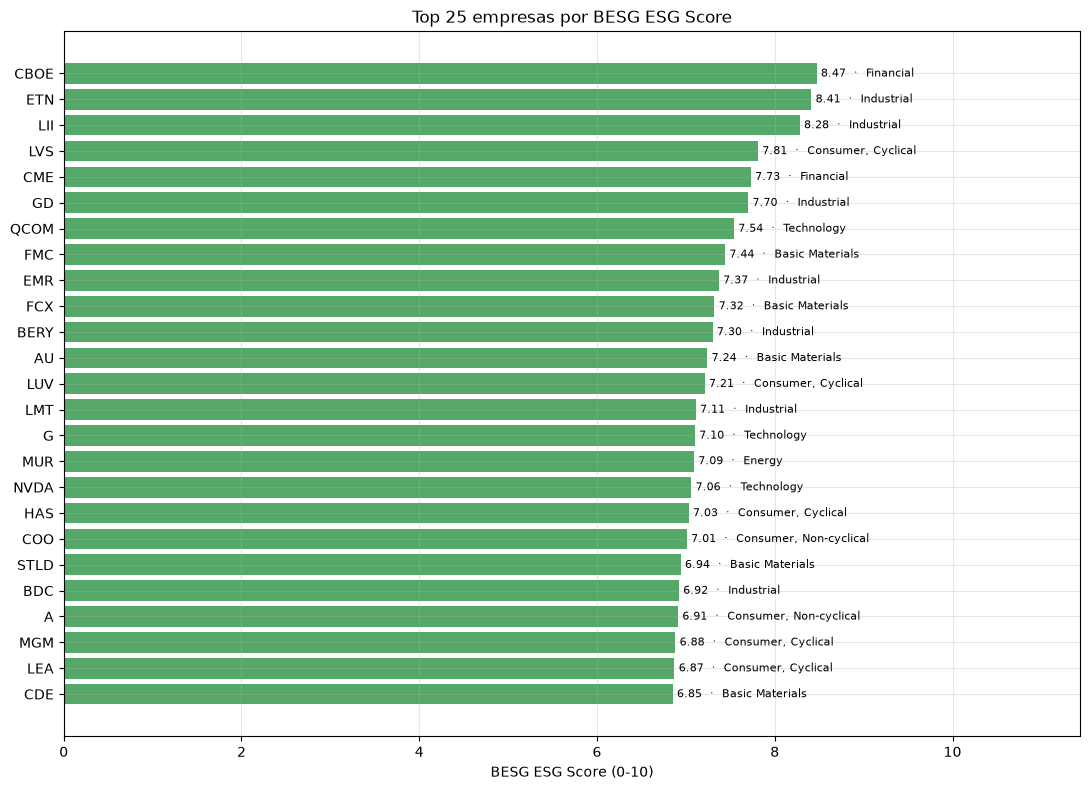

In [24]:
top = ranking.head(25).iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top["Simbolo"], top[COL_ESG], color="#55A868")
for y, (v, sec) in enumerate(zip(top[COL_ESG], top[SECTOR])):
    ax.text(v + 0.05, y, f"{v:.2f}  ·  {sec}", va="center", fontsize=8)
ax.set_xlim(0, top[COL_ESG].max() * 1.35)
ax.set_title("Top 25 empresas por BESG ESG Score")
ax.set_xlabel("BESG ESG Score (0-10)")
fig.tight_layout()
plt.show()

### 6.3 Líderes por sector


In [25]:
N_TOP = 5
lideres_sector = (
    ranking.sort_values([SECTOR, COL_ESG], ascending=[True, False])
    .groupby(SECTOR)
    .head(N_TOP)
    .set_index([SECTOR, "Puesto_sector"])[
        ["Simbolo", COL_ESG, COL_E, COL_S, COL_G, "Puesto", "Percentil"]
    ]
)
lideres_sector

Simbolo  BESG ESG Score  BESG Environmental Pillar Score  BESG Social Pillar Score  BESG Governance Pillar Score  Puesto  Percentil
Industry Sector        Puesto_sector                                                                                                                                    
Basic Materials        1                 FMC            7.44                             7.17                      8.54                          6.84       8      99.50
                       2                 FCX            7.32                             6.40                      7.75                          8.38      10      99.40
                       3                  AU            7.24                             5.34                      9.22                          7.44      12      99.20
                       4                STLD            6.94                             6.95                      6.28                          7.36      20      98.70
                       5                 CDE            6.85                             4.24                      8.89                          8.15      25      98.30
Communications         1                EBAY            6.82                             5.96                      6.64                          8.36      29      98.00
                       2                UBER            6.65                             6.99                      5.88                          7.65      41      97.20
                       3                 OMC            6.42                             7.50                      5.00                          8.32      71      95.00
                       4                MELI            5.95                             5.45                      6.78                          5.32     159      89.00
                       5                TMUS            5.88                             7.83                      4.55                          6.39     171      88.10
Consumer, Cyclical     1                 LVS            7.81                             8.57                      9.00                          5.14       4      99.80
                       2                 LUV            7.21                             7.42                      6.67                          7.80      13      99.20
                       3                 HAS            7.03                             3.72                      9.29                          7.23      18      98.80
                       4                 MGM            6.88                             6.16                      6.77                          8.09      23      98.50
                       5                 LEA            6.87                             4.66                      8.59                          7.34      24      98.40
Consumer, Non-cyclical 1                 COO            7.01                             1.50                      7.68                          8.31      19      98.70
                       2                   A            6.91                             3.00                      8.29                          6.24      22      98.50
                       3                 JNJ            6.79                             7.93                      5.82                          8.16      35      97.60
                       4                ILMN            6.68                             3.00                      7.05                          7.54      40      97.30
                       5                 ELV            6.65                             9.43                      5.70                          7.45      42      97.20
Energy                 1                 MUR            7.09                             6.95                      6.87                          7.55      16      99.00
                       2                 EQT            6.52                             6.61                      4.78                          8.31 

In [26]:
# El mejor y el peor de cada sector, uno al lado del otro
extremos = pd.concat(
    [
        ranking.loc[ranking.groupby(SECTOR)[COL_ESG].idxmax()].assign(posicion="Mejor"),
        ranking.loc[ranking.groupby(SECTOR)[COL_ESG].idxmin()].assign(posicion="Peor"),
    ]
).pivot_table(index=SECTOR, columns="posicion", values=COL_ESG, aggfunc="first")
extremos["brecha"] = extremos["Mejor"] - extremos["Peor"]
extremos.sort_values("brecha", ascending=False)

posicion,Mejor,Peor,brecha
Industry Sector,,,
Financial,8.47,1.05,7.42
"Consumer, Cyclical",7.81,0.78,7.03
Industrial,8.41,1.55,6.86
Technology,7.54,1.32,6.22
"Consumer, Non-cyclical",7.01,0.92,6.09
Communications,6.82,1.02,5.80
Energy,7.09,1.59,5.50
Basic Materials,7.44,2.27,5.17
Utilities,6.81,2.03,4.78


### 6.4 Ranking ajustado por sector (_z-score_ intrasectorial)El puntaje ESG bruto no es comparable entre sectores: una empresa de servicios públicosenfrenta exigencias ambientales distintas a una de tecnología. El _z-score_ dentro del sectormide cuántas desviaciones estándar se separa la empresa del promedio de sus pares directos.


In [27]:
g = ranking.groupby(SECTOR)[COL_ESG]
ranking["z_sector"] = (
    (ranking[COL_ESG] - g.transform("mean")) / g.transform("std")
).round(3)

ranking_z = ranking.sort_values("z_sector", ascending=False).reset_index(drop=True)[
    ["Simbolo", SECTOR, COL_ESG, "z_sector", "Puesto", "Puesto_sector", "N_sector"]
]
ranking_z.insert(0, "Puesto_z", np.arange(1, len(ranking_z) + 1))
print("Top 20 ajustado por sector:")
ranking_z.head(20)

Top 20 ajustado por sector:


,Puesto_z,Simbolo,Industry Sector,BESG ESG Score,z_sector,Puesto,Puesto_sector,N_sector
0,1,CBOE,Financial,8.47,3.48,1,1,306
1,2,CME,Financial,7.73,2.96,5,2,306
2,3,ETN,Industrial,8.41,2.71,2,1,208
3,4,LII,Industrial,8.28,2.62,3,2,208
4,5,QCOM,Technology,7.54,2.50,7,1,177
5,6,LVS,"Consumer, Cyclical",7.81,2.47,4,1,189
6,7,EBAY,Communications,6.82,2.35,29,1,94
7,8,BRX,Financial,6.84,2.35,26,3,306
8,9,BEN,Financial,6.72,2.26,37,4,306
9,10,EQIX,Financial,6.70,2.25,38,5,306


In [28]:
# Empresas donde el ranking bruto y el ajustado por sector más difieren
comparacion = ranking_z.assign(salto=lambda d: d["Puesto"] - d["Puesto_z"]).sort_values(
    "salto", ascending=False
)

print("Más beneficiadas al ajustar por sector (suben puestos):")
print(
    comparacion.head(10)[
        ["Simbolo", SECTOR, COL_ESG, "Puesto", "Puesto_z", "salto"]
    ].to_string(index=False)
)
print("\nMás perjudicadas al ajustar por sector (bajan puestos):")
print(
    comparacion.tail(10)[
        ["Simbolo", SECTOR, COL_ESG, "Puesto", "Puesto_z", "salto"]
    ].to_string(index=False)
)

Más beneficiadas al ajustar por sector (suben puestos):
Simbolo Industry Sector  BESG ESG Score  Puesto  Puesto_z  salto
    CPT       Financial            4.64     521       322    199
     XP       Financial            4.46     575       377    198
   CBRE       Financial            4.64     520       323    197
    MET       Financial            4.57     543       346    197
    WPC       Financial            4.83     474       277    197
    WFC       Financial            4.86     463       267    196
    WTW       Financial            4.61     530       334    196
    LXP       Financial            4.63     522       326    196
   SBRA       Financial            4.47     571       375    196
    APO       Financial            4.78     487       293    194

Más perjudicadas al ajustar por sector (bajan puestos):
Simbolo Industry Sector  BESG ESG Score  Puesto  Puesto_z  salto
    FUL Basic Materials            3.79     765      1144   -379
    OLN Basic Materials            3.12   

## 7. Relación entre ESG y variables financieras


In [29]:
VARS_INTERES = [
    "Current Market Cap",
    "Revenue",
    "Total Assets",
    "Number of Employees",
    "Return on Common Equity",
    "Return on Assets",
    "ROIC/WACC Ratio",
    "Gross Margin",
    "Operating Margin",
    "Price to Book Ratio",
    "Price Earnings Ratio (P/E)",
    "Financial Leverage",
    "Total Debt to Total Equity",
    "Total Debt to Total Assets",
    "Dividend 12 Month Yld - Gross",
    "Weighted Average Cost of Cap",
    "Board Size",
    "% Women on Board",
    "Board Diversity Percentage",
    "Independent Directors Board Meeting Attendance %",
]

correlaciones = pd.DataFrame(
    {
        "pearson": [esg[COL_ESG].corr(esg[v]) for v in VARS_INTERES],
        "spearman": [
            esg[COL_ESG].corr(esg[v], method="spearman") for v in VARS_INTERES
        ],
        "n": [esg[[COL_ESG, v]].dropna().shape[0] for v in VARS_INTERES],
    },
    index=VARS_INTERES,
).sort_values("spearman", ascending=False)
correlaciones

,pearson,spearman,n
Revenue,0.13,0.42,1433
Current Market Cap,0.14,0.38,1433
Board Size,0.34,0.37,424
Number of Employees,0.13,0.37,1395
% Women on Board,0.37,0.37,423
Total Assets,0.04,0.33,1432
Total Debt to Total Assets,0.18,0.26,1432
Total Debt to Total Equity,0.04,0.23,1372
Board Diversity Percentage,0.15,0.22,236
Return on Assets,0.17,0.15,1431


Se reporta también la correlación de Spearman porque varias variables financieras(_market cap_, ingresos, apalancamiento) tienen colas muy pesadas y valores atípicosque distorsionan el coeficiente de Pearson.


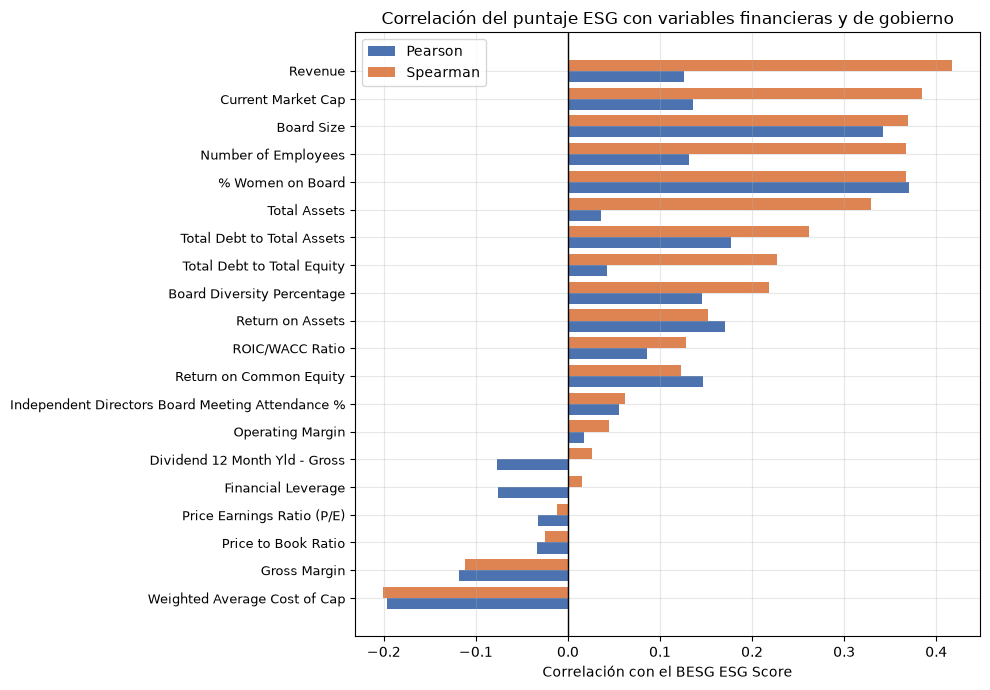

In [30]:
fig, ax = plt.subplots(figsize=(10, 7))
c = correlaciones.sort_values("spearman")
y = np.arange(len(c))
ax.barh(y - 0.2, c["pearson"], 0.4, label="Pearson", color="#4C72B0")
ax.barh(y + 0.2, c["spearman"], 0.4, label="Spearman", color="#DD8452")
ax.set_yticks(y, c.index, fontsize=9)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Correlación con el BESG ESG Score")
ax.set_title("Correlación del puntaje ESG con variables financieras y de gobierno")
ax.legend()
fig.tight_layout()
plt.show()

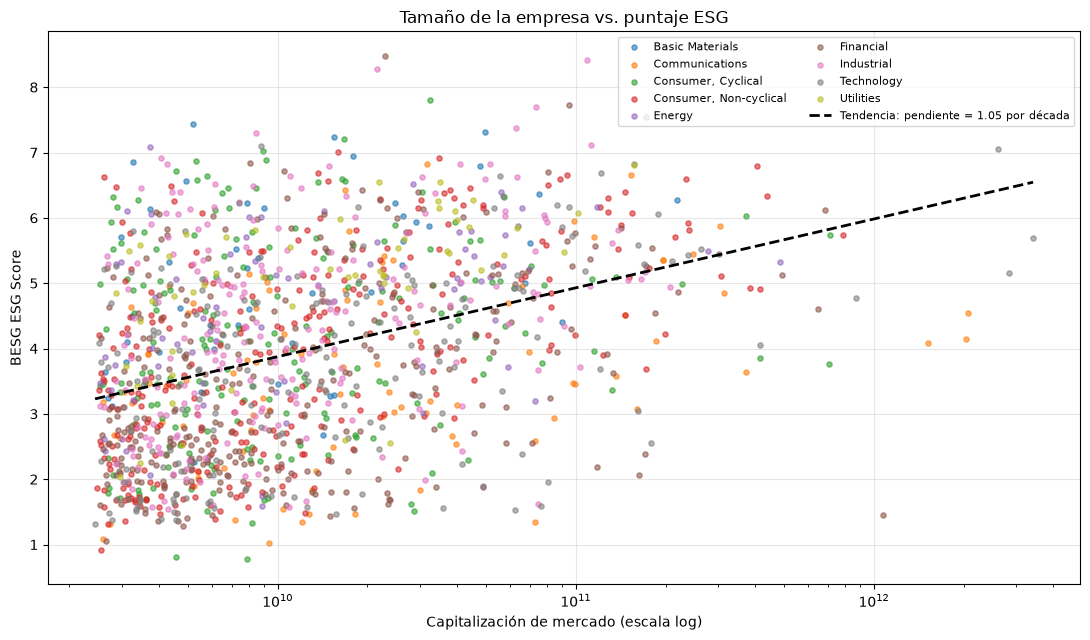

Correlación de Spearman entre ESG y log(market cap): 0.384  (n = 1,433)


In [31]:
# Tamaño vs. ESG: el market cap se grafica en escala logarítmica por su asimetría
muestra = esg[[COL_ESG, "Current Market Cap", SECTOR]].dropna()
muestra = muestra[muestra["Current Market Cap"] > 0]

fig, ax = plt.subplots(figsize=(11, 6.5))
for sector, grupo in muestra.groupby(SECTOR):
    ax.scatter(
        grupo["Current Market Cap"], grupo[COL_ESG], s=14, alpha=0.6, label=sector
    )
ax.set_xscale("log")
ax.set_xlabel("Capitalización de mercado (escala log)")
ax.set_ylabel("BESG ESG Score")
ax.set_title("Tamaño de la empresa vs. puntaje ESG")
ax.legend(fontsize=8, ncol=2)

# Tendencia lineal sobre el log del market cap
lx = np.log10(muestra["Current Market Cap"])
b, a = np.polyfit(lx, muestra[COL_ESG], 1)
xs = np.linspace(lx.min(), lx.max(), 100)
ax.plot(
    10**xs,
    a + b * xs,
    color="black",
    lw=2,
    ls="--",
    label=f"Tendencia: pendiente = {b:.2f} por década",
)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

rho = muestra[COL_ESG].corr(np.log10(muestra["Current Market Cap"]), method="spearman")
print(
    f"Correlación de Spearman entre ESG y log(market cap): {rho:.3f}  (n = {len(muestra):,})"
)

In [32]:
# ESG promedio por quintil de tamaño
q = esg[esg["Current Market Cap"] > 0].copy()
q["quintil_tamano"] = pd.qcut(
    q["Current Market Cap"],
    5,
    labels=["Q1 (más pequeñas)", "Q2", "Q3", "Q4", "Q5 (más grandes)"],
)
tabla_quintiles = q.groupby("quintil_tamano", observed=True)[[COL_ESG] + PILARES].agg(
    ["mean", "count"]
)
tabla_quintiles = tabla_quintiles.loc[:, (slice(None), "mean")].droplevel(1, axis=1)
tabla_quintiles["n"] = q.groupby("quintil_tamano", observed=True)[COL_ESG].count()
tabla_quintiles.rename(
    columns={COL_ESG: "ESG", COL_E: "Ambiental", COL_S: "Social", COL_G: "Gobernanza"}
)

,ESG,Ambiental,Social,Gobernanza,n
quintil_tamano,,,,,
Q1 (más pequeñas),3.30,1.89,2.61,6.71,287
Q2,3.54,2.15,2.97,6.88,286
Q3,3.72,2.56,3.09,6.81,287
Q4,4.38,3.31,3.86,6.96,286
Q5 (más grandes),4.91,4.52,3.90,7.25,287


## 8. Exportación de resultados


In [33]:
ARCHIVO_SALIDA = "resultados_esg.xlsx"

with pd.ExcelWriter(ARCHIVO_SALIDA, engine="openpyxl") as writer:
    describir(df, COLS_ESG_TODAS).to_excel(writer, sheet_name="desc_esg")
    describir(df, COLS_FIN).to_excel(writer, sheet_name="desc_financieras")
    describir(df, COLS_GOB).to_excel(writer, sheet_name="desc_gobierno")
    composicion.to_excel(writer, sheet_name="composicion_sector")
    stats_sector.to_excel(writer, sheet_name="esg_por_sector")
    pilares_sector.to_excel(writer, sheet_name="pilares_por_sector")
    ranking.to_excel(writer, sheet_name="ranking_global", index=False)
    ranking_z.to_excel(writer, sheet_name="ranking_ajustado", index=False)
    lideres_sector.to_excel(writer, sheet_name="lideres_por_sector")
    correlaciones.to_excel(writer, sheet_name="correlaciones")

print(f"Resultados exportados a {ARCHIVO_SALIDA}")

Resultados exportados a resultados_esg.xlsx


## 9. Resumen de hallazgos


In [34]:
lider = ranking.iloc[0]
ultimo = ranking.iloc[-1]
mejor_sector = stats_sector.index[0]
peor_sector = stats_sector.index[-1]

print("RESUMEN")
print("=" * 62)
print(f"Empresas en el archivo:            {len(df):,}")
print(
    f"Con puntaje ESG informado:         {len(esg):,} ({100 * len(esg) / len(df):.1f}%)"
)
print(f"Sectores:                          {df[SECTOR].nunique()}")
print(f"Año fiscal:                        {df['Year'].unique()[0]}")
print("-" * 62)
print(
    f"ESG medio / mediano:               {esg[COL_ESG].mean():.2f} / {esg[COL_ESG].median():.2f}"
)
print(f"Desviación estándar:               {esg[COL_ESG].std():.2f}")
print(
    f"Rango observado:                   {esg[COL_ESG].min():.2f} a {esg[COL_ESG].max():.2f}"
)
print("-" * 62)
print(
    f"Puesto 1:                          {lider['Simbolo']} ({lider[SECTOR]}) = {lider[COL_ESG]:.2f}"
)
print(
    f"Último puesto:                     {ultimo['Simbolo']} ({ultimo[SECTOR]}) = {ultimo[COL_ESG]:.2f}"
)
print(
    f"Sector con mayor ESG promedio:     {mejor_sector} = {stats_sector.loc[mejor_sector, 'media']:.2f}"
)
print(
    f"Sector con menor ESG promedio:     {peor_sector} = {stats_sector.loc[peor_sector, 'media']:.2f}"
)
print(f"Varianza del ESG explicada por el sector: {ss_entre / ss_total:.1%}")
print("=" * 62)

RESUMEN
Empresas en el archivo:            1,878
Con puntaje ESG informado:         1,433 (76.3%)
Sectores:                          10
Año fiscal:                        2023
--------------------------------------------------------------
ESG medio / mediano:               3.97 / 3.96
Desviación estándar:               1.52
Rango observado:                   0.78 a 8.47
--------------------------------------------------------------
Puesto 1:                          CBOE (Financial) = 8.47
Último puesto:                     LKNCY (Consumer, Cyclical) = 0.78
Sector con mayor ESG promedio:     Basic Materials = 5.04
Sector con menor ESG promedio:     Financial = 3.46
Varianza del ESG explicada por el sector: 8.2%


**Lecturas principales**- El puntaje ESG se concentra en la mitad baja de la escala 0-10: casi ninguna empresa se acerca al máximo teórico, así que el puntaje discrimina bien entre pares.- El pilar de gobernanza es sistemáticamente el más alto y el ambiental el más bajo, lo que refleja que las prácticas de gobierno están más estandarizadas y mejor divulgadas.- El sector explica una parte no trivial de la varianza del puntaje, por lo que comparar empresas de sectores distintos con el puntaje bruto es engañoso. Para eso está el ranking ajustado por _z-score_ intrasectorial de la sección 6.4.- El puntaje ESG correlaciona de forma positiva con el tamaño (capitalización, ingresos, empleados). Empresas grandes tienen más recursos para reportar, y buena parte del puntaje BESG depende del nivel de divulgación.- Las 445 empresas sin puntaje no son aleatorias: se concentran en las de menor tamaño, lo que introduce un sesgo de supervivencia en cualquier promedio del universo completo.

- `Funds` es el grupo más numeroso de la muestra (383 filas) y no son empresas
  operativas. Cualquier comparación entre sectores debe leerse con esa exclusión en mente.
